<div style="font-variant: small-caps; 
      font-weight: normal; 
      font-size: 37px; 
      text-align: center; 
      padding: 15px; 
      margin: 10px;">
  Machine Learning in credit scoring <br>
  </div> 

<div style="font-variant: small-caps; 
      font-weight: normal; 
      font-size: 25px; 
      text-align: center; 
      padding: 15px; 
      margin: 10px;">
      <font color=orange> Classification</font>
  </div>

<div style="font-variant: small-caps; 
      font-weight: normal; 
      font-size: 20px; 
      text-align: center; 
      padding: 15px; 
      margin: 10px;">
      Arystan, Sirine, Jules and Augustin
      
  </div>

# 1. Imporiting Libraries

In [ ]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier


from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import optuna

pd.set_option("display.max_columns", None)

/opt/miniconda3/envs/arystan_credit/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Data Loading

In [2]:
path_to_repo = Path('..').resolve()
path_to_data = path_to_repo / 'data'
path_to_model = path_to_repo / 'models'

In [3]:
df = pd.read_csv(path_to_data / 'preprocessed_data.csv')

In [4]:
y = df["bad"]
X = df.drop(columns=["bad", "ID"])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# RANDOM FOREST CLASSIFIER

In [6]:
rf_base = RandomForestClassifier(random_state=42)
%time rf_base.fit(X_train, y_train)

CPU times: user 1.09 s, sys: 52.5 ms, total: 1.14 s
Wall time: 1.17 s


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
y_pred_default = rf_base.predict(X_test)

In [8]:
print(classification_report(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7169
           1       0.33      0.14      0.19       123

    accuracy                           0.98      7292
   macro avg       0.66      0.57      0.59      7292
weighted avg       0.97      0.98      0.98      7292



- The dataset is highly imbalanced, so the default random forest model completely ignores the minority class

In [9]:
rf_default_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
%time rf_default_balanced.fit(X_train, y_train)

CPU times: user 1 s, sys: 23.9 ms, total: 1.02 s
Wall time: 1.03 s


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred_default_balanced = rf_default_balanced.predict(X_test)
print(classification_report(y_test, y_pred_default_balanced))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.17      0.35      0.23       123

    accuracy                           0.96      7292
   macro avg       0.58      0.66      0.60      7292
weighted avg       0.97      0.96      0.97      7292



- After balancing the classes using class_weight='balanced', the model performs slightly better on the minority class

In [11]:
feature_importance = pd.DataFrame({'feature': X.columns,'importance': rf_default_balanced.feature_importances_}).sort_values('importance', ascending=False)
feature_importance.head(20)

,feature,importance
13,AGE,0.220440
15,LOG_INCOME,0.208378
14,EXPERIENCE,0.142290
6,NAME_FAMILY_STATUS,0.050596
4,NAME_INCOME_TYPE,0.050519
12,CNT_FAM_MEMBERS,0.048632
5,NAME_EDUCATION_TYPE,0.044144
1,FLAG_OWN_CAR,0.035269
3,CNT_CHILDREN,0.034801
10,FLAG_PHONE,0.034329


- For our model most important features was age, log_income and work experience

In [12]:
rf_default_balanced_subsample = RandomForestClassifier(random_state=42,
                                    class_weight='balanced_subsample')
%time rf_default_balanced_subsample.fit(X_train, y_train)

CPU times: user 1.36 s, sys: 49.3 ms, total: 1.41 s
Wall time: 1.43 s


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
y_pred_default_balanced_subsample = rf_default_balanced_subsample.predict(X_test)
print(classification_report(y_test, y_pred_default_balanced_subsample))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.17      0.37      0.24       123

    accuracy                           0.96      7292
   macro avg       0.58      0.67      0.61      7292
weighted avg       0.98      0.96      0.97      7292



- So, class_weight='balanced' works by just multiplying the weights of the classes inversely proportional to their frequencies in the data
- and using subsample of the data for balancing gave slightly better by improving f1-score on the minority class by 4%
- it performed better because balanced_subsample calculates weights specifically for each tree's bootstrap sample

## RF + Hyperparameter Tuning

In [14]:
def objective_rf(trial, X_train, y_train, X_val, y_val):

    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 5, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 15)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    class_weight = trial.suggest_categorical("class_weight",
                                             ["balanced", "balanced_subsample"])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred)

    return f1

- We will tune hyperparameters using Optuna 

In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

We splitted data into 70% train, validation 15% and test 15%

In [16]:
db_path = path_to_model / "rf_opt.db"
storage_url = f"sqlite:///{db_path}"

In [17]:
study_rf = optuna.create_study(study_name="rf_opt", direction="maximize", storage=storage_url)

study_rf.optimize(lambda trial: objective_rf(trial, X_train, y_train, X_val, y_val),n_trials=50, show_progress_bar=True)

[I 2025-12-07 21:25:51,068] A new study created in RDB with name: rf_opt
Best trial: 0. Best value: 0.238683:   2%|▏         | 1/50 [00:00<00:33,  1.48it/s]

[I 2025-12-07 21:25:51,754] Trial 0 finished with value: 0.23868312757201646 and parameters: {'n_estimators': 168, 'max_depth': 18, 'min_samples_split': 15, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.23868312757201646.


Best trial: 0. Best value: 0.238683:   4%|▍         | 2/50 [00:01<00:27,  1.74it/s]

[I 2025-12-07 21:25:52,257] Trial 1 finished with value: 0.1736111111111111 and parameters: {'n_estimators': 163, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 5, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.23868312757201646.


Best trial: 0. Best value: 0.238683:   6%|▌         | 3/50 [00:01<00:30,  1.56it/s]

[I 2025-12-07 21:25:52,965] Trial 2 finished with value: 0.23293172690763053 and parameters: {'n_estimators': 229, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.23868312757201646.


Best trial: 0. Best value: 0.238683:   8%|▊         | 4/50 [00:02<00:34,  1.32it/s]

[I 2025-12-07 21:25:53,907] Trial 3 finished with value: 0.20224719101123595 and parameters: {'n_estimators': 118, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 8, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.23868312757201646.


Best trial: 0. Best value: 0.238683:  10%|█         | 5/50 [00:03<00:28,  1.60it/s]

[I 2025-12-07 21:25:54,305] Trial 4 finished with value: 0.08794788273615635 and parameters: {'n_estimators': 196, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.23868312757201646.


Best trial: 5. Best value: 0.261603:  12%|█▏        | 6/50 [00:04<00:32,  1.35it/s]

[I 2025-12-07 21:25:55,265] Trial 5 finished with value: 0.2616033755274262 and parameters: {'n_estimators': 232, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 1, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  14%|█▍        | 7/50 [00:05<00:34,  1.26it/s]

[I 2025-12-07 21:25:56,170] Trial 6 finished with value: 0.2551440329218107 and parameters: {'n_estimators': 206, 'max_depth': 23, 'min_samples_split': 12, 'min_samples_leaf': 7, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  16%|█▌        | 8/50 [00:05<00:31,  1.33it/s]

[I 2025-12-07 21:25:56,833] Trial 7 finished with value: 0.1780821917808219 and parameters: {'n_estimators': 184, 'max_depth': 10, 'min_samples_split': 14, 'min_samples_leaf': 4, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  18%|█▊        | 9/50 [00:06<00:25,  1.61it/s]

[I 2025-12-07 21:25:57,168] Trial 8 finished with value: 0.2459016393442623 and parameters: {'n_estimators': 73, 'max_depth': 27, 'min_samples_split': 15, 'min_samples_leaf': 2, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  20%|██        | 10/50 [00:06<00:26,  1.50it/s]

[I 2025-12-07 21:25:57,935] Trial 9 finished with value: 0.06140350877192982 and parameters: {'n_estimators': 138, 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 7, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  22%|██▏       | 11/50 [00:08<00:38,  1.00it/s]

[I 2025-12-07 21:25:59,680] Trial 10 finished with value: 0.25101214574898784 and parameters: {'n_estimators': 297, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 1, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  24%|██▍       | 12/50 [00:09<00:40,  1.07s/it]

[I 2025-12-07 21:26:00,900] Trial 11 finished with value: 0.25101214574898784 and parameters: {'n_estimators': 250, 'max_depth': 25, 'min_samples_split': 11, 'min_samples_leaf': 4, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  26%|██▌       | 13/50 [00:11<00:43,  1.19s/it]

[I 2025-12-07 21:26:02,373] Trial 12 finished with value: 0.25984251968503935 and parameters: {'n_estimators': 243, 'max_depth': 22, 'min_samples_split': 12, 'min_samples_leaf': 10, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  28%|██▊       | 14/50 [00:12<00:43,  1.20s/it]

[I 2025-12-07 21:26:03,604] Trial 13 finished with value: 0.25101214574898784 and parameters: {'n_estimators': 273, 'max_depth': 21, 'min_samples_split': 9, 'min_samples_leaf': 3, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  30%|███       | 15/50 [00:13<00:42,  1.21s/it]

[I 2025-12-07 21:26:04,837] Trial 14 finished with value: 0.25680933852140075 and parameters: {'n_estimators': 238, 'max_depth': 30, 'min_samples_split': 7, 'min_samples_leaf': 10, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  32%|███▏      | 16/50 [00:14<00:40,  1.18s/it]

[I 2025-12-07 21:26:05,957] Trial 15 finished with value: 0.24778761061946902 and parameters: {'n_estimators': 265, 'max_depth': 14, 'min_samples_split': 12, 'min_samples_leaf': 1, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  34%|███▍      | 17/50 [00:15<00:36,  1.11s/it]

[I 2025-12-07 21:26:06,885] Trial 16 finished with value: 0.2510460251046025 and parameters: {'n_estimators': 219, 'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 6, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  36%|███▌      | 18/50 [00:17<00:36,  1.14s/it]

[I 2025-12-07 21:26:08,095] Trial 17 finished with value: 0.24812030075187969 and parameters: {'n_estimators': 293, 'max_depth': 22, 'min_samples_split': 13, 'min_samples_leaf': 10, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  38%|███▊      | 19/50 [00:18<00:34,  1.12s/it]

[I 2025-12-07 21:26:09,167] Trial 18 finished with value: 0.24680851063829787 and parameters: {'n_estimators': 258, 'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 3, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  40%|████      | 20/50 [00:18<00:26,  1.14it/s]

[I 2025-12-07 21:26:09,477] Trial 19 finished with value: 0.23846153846153847 and parameters: {'n_estimators': 64, 'max_depth': 27, 'min_samples_split': 10, 'min_samples_leaf': 10, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  42%|████▏     | 21/50 [00:19<00:23,  1.25it/s]

[I 2025-12-07 21:26:10,093] Trial 20 finished with value: 0.25833333333333336 and parameters: {'n_estimators': 140, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 5, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  44%|████▍     | 22/50 [00:19<00:20,  1.39it/s]

[I 2025-12-07 21:26:10,623] Trial 21 finished with value: 0.2459016393442623 and parameters: {'n_estimators': 117, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 5, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  46%|████▌     | 23/50 [00:20<00:18,  1.45it/s]

[I 2025-12-07 21:26:11,252] Trial 22 finished with value: 0.24786324786324787 and parameters: {'n_estimators': 146, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 2, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  48%|████▊     | 24/50 [00:20<00:15,  1.63it/s]

[I 2025-12-07 21:26:11,682] Trial 23 finished with value: 0.2551440329218107 and parameters: {'n_estimators': 90, 'max_depth': 24, 'min_samples_split': 7, 'min_samples_leaf': 6, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  50%|█████     | 25/50 [00:21<00:17,  1.44it/s]

[I 2025-12-07 21:26:12,564] Trial 24 finished with value: 0.24701195219123506 and parameters: {'n_estimators': 206, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 9, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  52%|█████▏    | 26/50 [00:22<00:17,  1.40it/s]

[I 2025-12-07 21:26:13,333] Trial 25 finished with value: 0.2594142259414226 and parameters: {'n_estimators': 182, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 4, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  54%|█████▍    | 27/50 [00:23<00:18,  1.27it/s]

[I 2025-12-07 21:26:14,279] Trial 26 finished with value: 0.24892703862660945 and parameters: {'n_estimators': 225, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 2, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  56%|█████▌    | 28/50 [00:24<00:17,  1.24it/s]

[I 2025-12-07 21:26:15,141] Trial 27 finished with value: 0.2553191489361702 and parameters: {'n_estimators': 186, 'max_depth': 15, 'min_samples_split': 11, 'min_samples_leaf': 3, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  58%|█████▊    | 29/50 [00:25<00:19,  1.07it/s]

[I 2025-12-07 21:26:16,357] Trial 28 finished with value: 0.2543859649122807 and parameters: {'n_estimators': 247, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 4, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  60%|██████    | 30/50 [00:25<00:15,  1.28it/s]

[I 2025-12-07 21:26:16,787] Trial 29 finished with value: 0.2594142259414226 and parameters: {'n_estimators': 170, 'max_depth': 18, 'min_samples_split': 13, 'min_samples_leaf': 7, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  62%|██████▏   | 31/50 [00:26<00:17,  1.11it/s]

[I 2025-12-07 21:26:17,967] Trial 30 finished with value: 0.22580645161290322 and parameters: {'n_estimators': 279, 'max_depth': 12, 'min_samples_split': 11, 'min_samples_leaf': 9, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  64%|██████▍   | 32/50 [00:27<00:13,  1.33it/s]

[I 2025-12-07 21:26:18,370] Trial 31 finished with value: 0.24899598393574296 and parameters: {'n_estimators': 167, 'max_depth': 18, 'min_samples_split': 14, 'min_samples_leaf': 9, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  66%|██████▌   | 33/50 [00:27<00:10,  1.56it/s]

[I 2025-12-07 21:26:18,750] Trial 32 finished with value: 0.23931623931623933 and parameters: {'n_estimators': 160, 'max_depth': 17, 'min_samples_split': 13, 'min_samples_leaf': 6, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  68%|██████▊   | 34/50 [00:28<00:09,  1.70it/s]

[I 2025-12-07 21:26:19,222] Trial 33 finished with value: 0.256 and parameters: {'n_estimators': 206, 'max_depth': 22, 'min_samples_split': 15, 'min_samples_leaf': 7, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  70%|███████   | 35/50 [00:28<00:08,  1.85it/s]

[I 2025-12-07 21:26:19,646] Trial 34 finished with value: 0.2551440329218107 and parameters: {'n_estimators': 177, 'max_depth': 18, 'min_samples_split': 13, 'min_samples_leaf': 5, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  72%|███████▏  | 36/50 [00:29<00:07,  1.95it/s]

[I 2025-12-07 21:26:20,093] Trial 35 finished with value: 0.15789473684210525 and parameters: {'n_estimators': 218, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 7, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  74%|███████▍  | 37/50 [00:29<00:06,  1.93it/s]

[I 2025-12-07 21:26:20,622] Trial 36 finished with value: 0.24390243902439024 and parameters: {'n_estimators': 239, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  76%|███████▌  | 38/50 [00:29<00:05,  2.13it/s]

[I 2025-12-07 21:26:20,980] Trial 37 finished with value: 0.2572614107883817 and parameters: {'n_estimators': 118, 'max_depth': 20, 'min_samples_split': 14, 'min_samples_leaf': 4, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  78%|███████▊  | 39/50 [00:30<00:04,  2.25it/s]

[I 2025-12-07 21:26:21,364] Trial 38 finished with value: 0.2612244897959184 and parameters: {'n_estimators': 156, 'max_depth': 25, 'min_samples_split': 8, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  80%|████████  | 40/50 [00:30<00:04,  2.21it/s]

[I 2025-12-07 21:26:21,839] Trial 39 finished with value: 0.2530612244897959 and parameters: {'n_estimators': 192, 'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  82%|████████▏ | 41/50 [00:31<00:04,  1.94it/s]

[I 2025-12-07 21:26:22,500] Trial 40 finished with value: 0.24896265560165975 and parameters: {'n_estimators': 151, 'max_depth': 29, 'min_samples_split': 6, 'min_samples_leaf': 2, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  84%|████████▍ | 42/50 [00:31<00:03,  2.18it/s]

[I 2025-12-07 21:26:22,829] Trial 41 finished with value: 0.24793388429752067 and parameters: {'n_estimators': 129, 'max_depth': 24, 'min_samples_split': 7, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  86%|████████▌ | 43/50 [00:32<00:03,  2.04it/s]

[I 2025-12-07 21:26:23,393] Trial 42 finished with value: 0.2553191489361702 and parameters: {'n_estimators': 158, 'max_depth': 22, 'min_samples_split': 10, 'min_samples_leaf': 3, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  88%|████████▊ | 44/50 [00:32<00:02,  2.08it/s]

[I 2025-12-07 21:26:23,853] Trial 43 finished with value: 0.25101214574898784 and parameters: {'n_estimators': 180, 'max_depth': 24, 'min_samples_split': 4, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  90%|█████████ | 45/50 [00:33<00:02,  2.07it/s]

[I 2025-12-07 21:26:24,342] Trial 44 finished with value: 0.25196850393700787 and parameters: {'n_estimators': 208, 'max_depth': 28, 'min_samples_split': 12, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  92%|█████████▏| 46/50 [00:33<00:01,  2.41it/s]

[I 2025-12-07 21:26:24,599] Trial 45 finished with value: 0.2542372881355932 and parameters: {'n_estimators': 102, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 2, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  94%|█████████▍| 47/50 [00:34<00:01,  1.99it/s]

[I 2025-12-07 21:26:25,300] Trial 46 finished with value: 0.20242914979757085 and parameters: {'n_estimators': 169, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 3, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  96%|█████████▌| 48/50 [00:34<00:00,  2.05it/s]

[I 2025-12-07 21:26:25,753] Trial 47 finished with value: 0.24899598393574296 and parameters: {'n_estimators': 192, 'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 9, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603:  98%|█████████▊| 49/50 [00:35<00:00,  1.58it/s]

[I 2025-12-07 21:26:26,725] Trial 48 finished with value: 0.2457627118644068 and parameters: {'n_estimators': 231, 'max_depth': 16, 'min_samples_split': 11, 'min_samples_leaf': 2, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


Best trial: 5. Best value: 0.261603: 100%|██████████| 50/50 [00:36<00:00,  1.38it/s]

[I 2025-12-07 21:26:27,313] Trial 49 finished with value: 0.25203252032520324 and parameters: {'n_estimators': 133, 'max_depth': 26, 'min_samples_split': 13, 'min_samples_leaf': 8, 'class_weight': 'balanced_subsample'}. Best is trial 5 with value: 0.2616033755274262.


In [18]:
print("Best F1:", study_rf.best_value)
print("Best params:", study_rf.best_params)

Best F1: 0.2616033755274262
Best params: {'n_estimators': 232, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 1, 'class_weight': 'balanced_subsample'}


In [19]:
best_params = study_rf.best_params

best_rf = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

y_pred_best = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      5376
           1       0.18      0.35      0.24        93

    accuracy                           0.96      5469
   macro avg       0.58      0.66      0.61      5469
weighted avg       0.97      0.96      0.97      5469



We can see that after hyperparameter tuning, our recall decreased by 2% buy improved f1-score by 1%

## RF + SMOTE + Hyperparameter Tuning

In [20]:
def objective_rf_smote(trial, X_train, y_train, X_val, y_val):
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 5, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    class_weight = trial.suggest_categorical("class_weight",
                                             ["balanced", "balanced_subsample"])

    smote = SMOTE(sampling_strategy=0.3, random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_val)

    f1 = f1_score(y_val, y_pred)

    return f1

We used SMOTE to generate synthetic data for the minority class in the training set only. It works by creating new data points mathematically located between existing minority class data points

In [21]:
db_path = path_to_model / "rf_smote_opt.db"
storage_url = f"sqlite:///{db_path}"

In [22]:
study_rf_smote = optuna.create_study(study_name="rf_smote_opt", direction="maximize", storage=storage_url)

[I 2025-12-07 21:26:28,418] A new study created in RDB with name: rf_smote_opt


In [23]:
study_rf_smote.optimize(lambda trial: objective_rf_smote(trial, X_train, y_train, X_val, y_val), n_trials=50, show_progress_bar=True)

Best trial: 0. Best value: 0.0350282:   2%|▏         | 1/50 [00:00<00:43,  1.13it/s]

[I 2025-12-07 21:26:29,316] Trial 0 finished with value: 0.03502824858757062 and parameters: {'n_estimators': 176, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 9, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.03502824858757062.


Best trial: 1. Best value: 0.091954:   4%|▍         | 2/50 [00:01<00:36,  1.33it/s] 

[I 2025-12-07 21:26:29,975] Trial 1 finished with value: 0.09195402298850575 and parameters: {'n_estimators': 245, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 6, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.09195402298850575.


Best trial: 2. Best value: 0.113725:   6%|▌         | 3/50 [00:01<00:26,  1.75it/s]

[I 2025-12-07 21:26:30,330] Trial 2 finished with value: 0.11372549019607843 and parameters: {'n_estimators': 124, 'max_depth': 17, 'min_samples_split': 16, 'min_samples_leaf': 9, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.11372549019607843.


Best trial: 3. Best value: 0.239044:   8%|▊         | 4/50 [00:02<00:28,  1.62it/s]

[I 2025-12-07 21:26:31,021] Trial 3 finished with value: 0.23904382470119523 and parameters: {'n_estimators': 235, 'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.23904382470119523.


Best trial: 3. Best value: 0.239044:  10%|█         | 5/50 [00:02<00:24,  1.85it/s]

[I 2025-12-07 21:26:31,424] Trial 4 finished with value: 0.1712707182320442 and parameters: {'n_estimators': 135, 'max_depth': 27, 'min_samples_split': 5, 'min_samples_leaf': 7, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.23904382470119523.


Best trial: 3. Best value: 0.239044:  12%|█▏        | 6/50 [00:03<00:24,  1.83it/s]

[I 2025-12-07 21:26:31,985] Trial 5 finished with value: 0.13963963963963963 and parameters: {'n_estimators': 101, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 4, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.23904382470119523.


Best trial: 3. Best value: 0.239044:  14%|█▍        | 7/50 [00:03<00:21,  2.01it/s]

[I 2025-12-07 21:26:32,377] Trial 6 finished with value: 0.17366946778711484 and parameters: {'n_estimators': 109, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 5, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.23904382470119523.


Best trial: 3. Best value: 0.239044:  16%|█▌        | 8/50 [00:05<00:30,  1.37it/s]

[I 2025-12-07 21:26:33,610] Trial 7 finished with value: 0.05714285714285714 and parameters: {'n_estimators': 181, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 9, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.23904382470119523.


Best trial: 3. Best value: 0.239044:  18%|█▊        | 9/50 [00:06<00:36,  1.13it/s]

[I 2025-12-07 21:26:34,840] Trial 8 finished with value: 0.04924543288324067 and parameters: {'n_estimators': 231, 'max_depth': 7, 'min_samples_split': 11, 'min_samples_leaf': 9, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.23904382470119523.


Best trial: 3. Best value: 0.239044:  20%|██        | 10/50 [00:07<00:36,  1.10it/s]

[I 2025-12-07 21:26:35,804] Trial 9 finished with value: 0.1806853582554517 and parameters: {'n_estimators': 294, 'max_depth': 26, 'min_samples_split': 14, 'min_samples_leaf': 5, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.23904382470119523.


Best trial: 3. Best value: 0.239044:  22%|██▏       | 11/50 [00:07<00:29,  1.33it/s]

[I 2025-12-07 21:26:36,195] Trial 10 finished with value: 0.2074074074074074 and parameters: {'n_estimators': 51, 'max_depth': 23, 'min_samples_split': 19, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.23904382470119523.


Best trial: 3. Best value: 0.239044:  24%|██▍       | 12/50 [00:08<00:23,  1.65it/s]

[I 2025-12-07 21:26:36,467] Trial 11 finished with value: 0.199288256227758 and parameters: {'n_estimators': 61, 'max_depth': 23, 'min_samples_split': 20, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.23904382470119523.


Best trial: 12. Best value: 0.247788:  26%|██▌       | 13/50 [00:08<00:24,  1.51it/s]

[I 2025-12-07 21:26:37,256] Trial 12 finished with value: 0.24778761061946902 and parameters: {'n_estimators': 240, 'max_depth': 29, 'min_samples_split': 11, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 12 with value: 0.24778761061946902.


Best trial: 12. Best value: 0.247788:  28%|██▊       | 14/50 [00:09<00:24,  1.48it/s]

[I 2025-12-07 21:26:37,971] Trial 13 finished with value: 0.22393822393822393 and parameters: {'n_estimators': 236, 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 3, 'class_weight': 'balanced'}. Best is trial 12 with value: 0.24778761061946902.


Best trial: 12. Best value: 0.247788:  30%|███       | 15/50 [00:10<00:25,  1.36it/s]

[I 2025-12-07 21:26:38,846] Trial 14 finished with value: 0.23868312757201646 and parameters: {'n_estimators': 284, 'max_depth': 30, 'min_samples_split': 13, 'min_samples_leaf': 2, 'class_weight': 'balanced'}. Best is trial 12 with value: 0.24778761061946902.


Best trial: 12. Best value: 0.247788:  32%|███▏      | 16/50 [00:10<00:23,  1.46it/s]

[I 2025-12-07 21:26:39,406] Trial 15 finished with value: 0.07262569832402235 and parameters: {'n_estimators': 207, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 3, 'class_weight': 'balanced'}. Best is trial 12 with value: 0.24778761061946902.


Best trial: 12. Best value: 0.247788:  34%|███▍      | 17/50 [00:11<00:23,  1.42it/s]

[I 2025-12-07 21:26:40,160] Trial 16 finished with value: 0.21641791044776118 and parameters: {'n_estimators': 256, 'max_depth': 21, 'min_samples_split': 9, 'min_samples_leaf': 2, 'class_weight': 'balanced'}. Best is trial 12 with value: 0.24778761061946902.


Best trial: 17. Best value: 0.257511:  36%|███▌      | 18/50 [00:12<00:21,  1.47it/s]

[I 2025-12-07 21:26:40,779] Trial 17 finished with value: 0.2575107296137339 and parameters: {'n_estimators': 206, 'max_depth': 26, 'min_samples_split': 12, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  38%|███▊      | 19/50 [00:13<00:24,  1.25it/s]

[I 2025-12-07 21:26:41,870] Trial 18 finished with value: 0.22058823529411764 and parameters: {'n_estimators': 205, 'max_depth': 27, 'min_samples_split': 12, 'min_samples_leaf': 3, 'class_weight': 'balanced_subsample'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  40%|████      | 20/50 [00:13<00:20,  1.43it/s]

[I 2025-12-07 21:26:42,326] Trial 19 finished with value: 0.17079889807162535 and parameters: {'n_estimators': 147, 'max_depth': 25, 'min_samples_split': 17, 'min_samples_leaf': 7, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  42%|████▏     | 21/50 [00:14<00:21,  1.37it/s]

[I 2025-12-07 21:26:43,135] Trial 20 finished with value: 0.24489795918367346 and parameters: {'n_estimators': 273, 'max_depth': 29, 'min_samples_split': 11, 'min_samples_leaf': 2, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  44%|████▍     | 22/50 [00:15<00:21,  1.30it/s]

[I 2025-12-07 21:26:43,996] Trial 21 finished with value: 0.24390243902439024 and parameters: {'n_estimators': 270, 'max_depth': 29, 'min_samples_split': 11, 'min_samples_leaf': 2, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  46%|████▌     | 23/50 [00:16<00:22,  1.20it/s]

[I 2025-12-07 21:26:44,987] Trial 22 finished with value: 0.2543859649122807 and parameters: {'n_estimators': 205, 'max_depth': 28, 'min_samples_split': 13, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  48%|████▊     | 24/50 [00:17<00:20,  1.29it/s]

[I 2025-12-07 21:26:45,626] Trial 23 finished with value: 0.24489795918367346 and parameters: {'n_estimators': 208, 'max_depth': 24, 'min_samples_split': 13, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  50%|█████     | 25/50 [00:17<00:17,  1.44it/s]

[I 2025-12-07 21:26:46,126] Trial 24 finished with value: 0.20202020202020202 and parameters: {'n_estimators': 159, 'max_depth': 27, 'min_samples_split': 14, 'min_samples_leaf': 4, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  52%|█████▏    | 26/50 [00:18<00:16,  1.47it/s]

[I 2025-12-07 21:26:46,769] Trial 25 finished with value: 0.17964071856287425 and parameters: {'n_estimators': 195, 'max_depth': 19, 'min_samples_split': 17, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  54%|█████▍    | 27/50 [00:19<00:19,  1.15it/s]

[I 2025-12-07 21:26:48,083] Trial 26 finished with value: 0.23015873015873015 and parameters: {'n_estimators': 221, 'max_depth': 27, 'min_samples_split': 9, 'min_samples_leaf': 3, 'class_weight': 'balanced_subsample'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  56%|█████▌    | 28/50 [00:20<00:18,  1.20it/s]

[I 2025-12-07 21:26:48,842] Trial 27 finished with value: 0.23529411764705882 and parameters: {'n_estimators': 254, 'max_depth': 24, 'min_samples_split': 13, 'min_samples_leaf': 2, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  58%|█████▊    | 29/50 [00:21<00:16,  1.31it/s]

[I 2025-12-07 21:26:49,438] Trial 28 finished with value: 0.1901639344262295 and parameters: {'n_estimators': 183, 'max_depth': 28, 'min_samples_split': 15, 'min_samples_leaf': 4, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  60%|██████    | 30/50 [00:21<00:16,  1.24it/s]

[I 2025-12-07 21:26:50,332] Trial 29 finished with value: 0.1345707656612529 and parameters: {'n_estimators': 164, 'max_depth': 25, 'min_samples_split': 9, 'min_samples_leaf': 10, 'class_weight': 'balanced_subsample'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  62%|██████▏   | 31/50 [00:22<00:14,  1.29it/s]

[I 2025-12-07 21:26:51,035] Trial 30 finished with value: 0.21505376344086022 and parameters: {'n_estimators': 221, 'max_depth': 22, 'min_samples_split': 18, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  64%|██████▍   | 32/50 [00:23<00:14,  1.27it/s]

[I 2025-12-07 21:26:51,855] Trial 31 finished with value: 0.23529411764705882 and parameters: {'n_estimators': 272, 'max_depth': 30, 'min_samples_split': 11, 'min_samples_leaf': 2, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  66%|██████▌   | 33/50 [00:24<00:15,  1.10it/s]

[I 2025-12-07 21:26:53,060] Trial 32 finished with value: 0.24066390041493776 and parameters: {'n_estimators': 264, 'max_depth': 29, 'min_samples_split': 12, 'min_samples_leaf': 2, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 17. Best value: 0.257511:  68%|██████▊   | 34/50 [00:25<00:13,  1.18it/s]

[I 2025-12-07 21:26:53,757] Trial 33 finished with value: 0.2465753424657534 and parameters: {'n_estimators': 190, 'max_depth': 28, 'min_samples_split': 10, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.2575107296137339.


Best trial: 34. Best value: 0.26601:  70%|███████   | 35/50 [00:26<00:12,  1.23it/s] 

[I 2025-12-07 21:26:54,483] Trial 34 finished with value: 0.2660098522167488 and parameters: {'n_estimators': 193, 'max_depth': 26, 'min_samples_split': 7, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  72%|███████▏  | 36/50 [00:26<00:10,  1.30it/s]

[I 2025-12-07 21:26:55,155] Trial 35 finished with value: 0.12033195020746888 and parameters: {'n_estimators': 166, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  74%|███████▍  | 37/50 [00:27<00:11,  1.13it/s]

[I 2025-12-07 21:26:56,297] Trial 36 finished with value: 0.16574585635359115 and parameters: {'n_estimators': 221, 'max_depth': 25, 'min_samples_split': 4, 'min_samples_leaf': 7, 'class_weight': 'balanced'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  76%|███████▌  | 38/50 [00:28<00:10,  1.12it/s]

[I 2025-12-07 21:26:57,221] Trial 37 finished with value: 0.23387096774193547 and parameters: {'n_estimators': 237, 'max_depth': 28, 'min_samples_split': 7, 'min_samples_leaf': 3, 'class_weight': 'balanced'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  78%|███████▊  | 39/50 [00:29<00:10,  1.05it/s]

[I 2025-12-07 21:26:58,310] Trial 38 finished with value: 0.1744186046511628 and parameters: {'n_estimators': 196, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 6, 'class_weight': 'balanced_subsample'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  80%|████████  | 40/50 [00:30<00:08,  1.13it/s]

[I 2025-12-07 21:26:59,043] Trial 39 finished with value: 0.18983050847457628 and parameters: {'n_estimators': 247, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  82%|████████▏ | 41/50 [00:31<00:06,  1.29it/s]

[I 2025-12-07 21:26:59,567] Trial 40 finished with value: 0.11299435028248588 and parameters: {'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 4, 'class_weight': 'balanced'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  84%|████████▍ | 42/50 [00:31<00:05,  1.39it/s]

[I 2025-12-07 21:27:00,151] Trial 41 finished with value: 0.25 and parameters: {'n_estimators': 187, 'max_depth': 28, 'min_samples_split': 10, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  86%|████████▌ | 43/50 [00:32<00:04,  1.53it/s]

[I 2025-12-07 21:27:00,644] Trial 42 finished with value: 0.2413793103448276 and parameters: {'n_estimators': 149, 'max_depth': 26, 'min_samples_split': 7, 'min_samples_leaf': 2, 'class_weight': 'balanced'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  88%|████████▊ | 44/50 [00:32<00:03,  1.54it/s]

[I 2025-12-07 21:27:01,295] Trial 43 finished with value: 0.2575107296137339 and parameters: {'n_estimators': 214, 'max_depth': 28, 'min_samples_split': 12, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  90%|█████████ | 45/50 [00:33<00:03,  1.56it/s]

[I 2025-12-07 21:27:01,918] Trial 44 finished with value: 0.15223097112860892 and parameters: {'n_estimators': 209, 'max_depth': 23, 'min_samples_split': 12, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  92%|█████████▏| 46/50 [00:34<00:02,  1.52it/s]

[I 2025-12-07 21:27:02,616] Trial 45 finished with value: 0.2459016393442623 and parameters: {'n_estimators': 185, 'max_depth': 26, 'min_samples_split': 14, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  94%|█████████▍| 47/50 [00:35<00:02,  1.22it/s]

[I 2025-12-07 21:27:03,815] Trial 46 finished with value: 0.25217391304347825 and parameters: {'n_estimators': 219, 'max_depth': 24, 'min_samples_split': 6, 'min_samples_leaf': 2, 'class_weight': 'balanced_subsample'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  96%|█████████▌| 48/50 [00:36<00:01,  1.05it/s]

[I 2025-12-07 21:27:05,059] Trial 47 finished with value: 0.2247191011235955 and parameters: {'n_estimators': 226, 'max_depth': 21, 'min_samples_split': 6, 'min_samples_leaf': 2, 'class_weight': 'balanced_subsample'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601:  98%|█████████▊| 49/50 [00:37<00:00,  1.12it/s]

[I 2025-12-07 21:27:05,817] Trial 48 finished with value: 0.2196969696969697 and parameters: {'n_estimators': 129, 'max_depth': 24, 'min_samples_split': 5, 'min_samples_leaf': 3, 'class_weight': 'balanced_subsample'}. Best is trial 34 with value: 0.2660098522167488.


Best trial: 34. Best value: 0.26601: 100%|██████████| 50/50 [00:38<00:00,  1.30it/s]

[I 2025-12-07 21:27:06,805] Trial 49 finished with value: 0.03506787330316742 and parameters: {'n_estimators': 215, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 1, 'class_weight': 'balanced_subsample'}. Best is trial 34 with value: 0.2660098522167488.


In [24]:
best_params = study_rf_smote.best_params

smote = SMOTE(sampling_strategy=0.3, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

final_rf_smote = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

final_rf_smote.fit(X_train_res, y_train_res)

,n_estimators,193
,criterion,'gini'
,max_depth,26
,min_samples_split,7
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred_test = final_rf_smote.predict(X_test)
print(classification_report(y_test, y_pred_test))


              precision    recall  f1-score   support

           0       0.99      0.98      0.98      5376
           1       0.21      0.31      0.25        93

    accuracy                           0.97      5469
   macro avg       0.60      0.65      0.62      5469
weighted avg       0.97      0.97      0.97      5469



So after applying SMOTE and hyperparameter tuning, we improved precision by 2% and f1-score by 1% but recall decreased by 1% in minority class. We can conclude that we did everything possible to improve model performance on imbalanced data, but macro avg f1-score is still 0.61 

# XGBOOST CLASSIFIER

## XGBOOST + Hyperparameter Tuning

In [26]:
def objective_xgb(trial, X_train, y_train, X_val, y_val):

    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),        
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 50),
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist",
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    y_pred_val = model.predict(X_val)

    return f1_score(y_val, y_pred_val)

In [27]:
db_path = path_to_model / "xgb_class_opt.db"
storage_url = f"sqlite:///{db_path}"

In [28]:
study_xgb = optuna.create_study(study_name="xgb_class_opt", direction="maximize", storage=storage_url)
study_xgb.optimize(lambda trial: objective_xgb(trial, X_train, y_train, X_val, y_val), n_trials=50, show_progress_bar=True)

[I 2025-12-07 21:27:07,543] A new study created in RDB with name: xgb_class_opt
Best trial: 0. Best value: 0.229607:   2%|▏         | 1/50 [00:00<00:11,  4.16it/s]

[I 2025-12-07 21:27:07,781] Trial 0 finished with value: 0.229607250755287 and parameters: {'learning_rate': 0.2470806450619909, 'max_depth': 10, 'n_estimators': 357, 'subsample': 0.9631791980302984, 'colsample_bytree': 0.6672969856661651, 'gamma': 5.162394227039716, 'min_child_weight': 4, 'scale_pos_weight': 49.77998070353887}. Best is trial 0 with value: 0.229607250755287.


Best trial: 1. Best value: 0.232044:   4%|▍         | 2/50 [00:00<00:14,  3.32it/s]

[I 2025-12-07 21:27:08,125] Trial 1 finished with value: 0.23204419889502761 and parameters: {'learning_rate': 0.08555090307992592, 'max_depth': 6, 'n_estimators': 237, 'subsample': 0.7061850384819705, 'colsample_bytree': 0.8472555838022913, 'gamma': 2.0618516224408534, 'min_child_weight': 27, 'scale_pos_weight': 13.59081630405897}. Best is trial 1 with value: 0.23204419889502761.


Best trial: 2. Best value: 0.258427:   6%|▌         | 3/50 [00:01<00:21,  2.16it/s]

[I 2025-12-07 21:27:08,780] Trial 2 finished with value: 0.25842696629213485 and parameters: {'learning_rate': 0.05085827862409101, 'max_depth': 11, 'n_estimators': 291, 'subsample': 0.6107750679261413, 'colsample_bytree': 0.6592943733223499, 'gamma': 0.028684244115996238, 'min_child_weight': 24, 'scale_pos_weight': 11.784568876230699}. Best is trial 2 with value: 0.25842696629213485.


Best trial: 2. Best value: 0.258427:   8%|▊         | 4/50 [00:01<00:19,  2.39it/s]

[I 2025-12-07 21:27:09,133] Trial 3 finished with value: 0.0392156862745098 and parameters: {'learning_rate': 0.10339879091596496, 'max_depth': 10, 'n_estimators': 711, 'subsample': 0.8764564239546259, 'colsample_bytree': 0.7926884626481164, 'gamma': 8.221083253090494, 'min_child_weight': 29, 'scale_pos_weight': 5.337059603803485}. Best is trial 2 with value: 0.25842696629213485.


Best trial: 2. Best value: 0.258427:  10%|█         | 5/50 [00:02<00:19,  2.35it/s]

[I 2025-12-07 21:27:09,569] Trial 4 finished with value: 0.23125 and parameters: {'learning_rate': 0.08108902371920718, 'max_depth': 7, 'n_estimators': 292, 'subsample': 0.8508942118941653, 'colsample_bytree': 0.8765407739708473, 'gamma': 4.672187429835153, 'min_child_weight': 10, 'scale_pos_weight': 48.0795181978735}. Best is trial 2 with value: 0.25842696629213485.


Best trial: 5. Best value: 0.317647:  12%|█▏        | 6/50 [00:02<00:25,  1.69it/s]

[I 2025-12-07 21:27:10,479] Trial 5 finished with value: 0.3176470588235294 and parameters: {'learning_rate': 0.05215238256341327, 'max_depth': 5, 'n_estimators': 800, 'subsample': 0.8280469562705655, 'colsample_bytree': 0.913893878001085, 'gamma': 2.243257923289419, 'min_child_weight': 7, 'scale_pos_weight': 8.020278634575982}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  14%|█▍        | 7/50 [00:03<00:23,  1.79it/s]

[I 2025-12-07 21:27:10,970] Trial 6 finished with value: 0.25925925925925924 and parameters: {'learning_rate': 0.19619137252285626, 'max_depth': 7, 'n_estimators': 471, 'subsample': 0.8384380212053685, 'colsample_bytree': 0.7130583946707875, 'gamma': 2.8340142898101273, 'min_child_weight': 24, 'scale_pos_weight': 7.119706152527946}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  16%|█▌        | 8/50 [00:03<00:22,  1.87it/s]

[I 2025-12-07 21:27:11,454] Trial 7 finished with value: 0.25 and parameters: {'learning_rate': 0.1705521234722658, 'max_depth': 11, 'n_estimators': 426, 'subsample': 0.6293993036084459, 'colsample_bytree': 0.6019228132496578, 'gamma': 9.849528392165407, 'min_child_weight': 14, 'scale_pos_weight': 22.530522789897553}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  18%|█▊        | 9/50 [00:04<00:19,  2.11it/s]

[I 2025-12-07 21:27:11,798] Trial 8 finished with value: 0.2781954887218045 and parameters: {'learning_rate': 0.12287582600150813, 'max_depth': 7, 'n_estimators': 217, 'subsample': 0.8143783219235465, 'colsample_bytree': 0.9500124041894262, 'gamma': 3.3634007786225153, 'min_child_weight': 7, 'scale_pos_weight': 24.0691629595596}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  20%|██        | 10/50 [00:04<00:19,  2.06it/s]

[I 2025-12-07 21:27:12,305] Trial 9 finished with value: 0.24060150375939848 and parameters: {'learning_rate': 0.0423761897666509, 'max_depth': 6, 'n_estimators': 377, 'subsample': 0.7880013501912597, 'colsample_bytree': 0.9399761451901717, 'gamma': 8.514598003668821, 'min_child_weight': 17, 'scale_pos_weight': 26.94248697475755}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  22%|██▏       | 11/50 [00:05<00:20,  1.88it/s]

[I 2025-12-07 21:27:12,938] Trial 10 finished with value: 0.0862533692722372 and parameters: {'learning_rate': 0.01575718844005603, 'max_depth': 3, 'n_estimators': 761, 'subsample': 0.9730580199345872, 'colsample_bytree': 0.9902173407921374, 'gamma': 0.15555582090732933, 'min_child_weight': 1, 'scale_pos_weight': 35.64238676311752}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  24%|██▍       | 12/50 [00:06<00:26,  1.44it/s]

[I 2025-12-07 21:27:14,014] Trial 11 finished with value: 0.2835820895522388 and parameters: {'learning_rate': 0.13171500999467656, 'max_depth': 4, 'n_estimators': 613, 'subsample': 0.759369556845404, 'colsample_bytree': 0.9305339660520775, 'gamma': 3.671340172542916, 'min_child_weight': 8, 'scale_pos_weight': 19.980058323072207}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  26%|██▌       | 13/50 [00:07<00:29,  1.27it/s]

[I 2025-12-07 21:27:15,022] Trial 12 finished with value: 0.228310502283105 and parameters: {'learning_rate': 0.14526122477519327, 'max_depth': 3, 'n_estimators': 607, 'subsample': 0.7424614002869077, 'colsample_bytree': 0.8978838401958638, 'gamma': 4.57643462472797, 'min_child_weight': 10, 'scale_pos_weight': 16.107855571312946}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  28%|██▊       | 14/50 [00:07<00:22,  1.57it/s]

[I 2025-12-07 21:27:15,300] Trial 13 finished with value: 0.0 and parameters: {'learning_rate': 0.22777524566837576, 'max_depth': 4, 'n_estimators': 590, 'subsample': 0.7093180992591986, 'colsample_bytree': 0.8038102113137607, 'gamma': 5.94447589055177, 'min_child_weight': 14, 'scale_pos_weight': 1.812928130480441}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  30%|███       | 15/50 [00:08<00:24,  1.43it/s]

[I 2025-12-07 21:27:16,154] Trial 14 finished with value: 0.26618705035971224 and parameters: {'learning_rate': 0.17851998787901596, 'max_depth': 5, 'n_estimators': 799, 'subsample': 0.9099719582908785, 'colsample_bytree': 0.9857737180763275, 'gamma': 1.8001837007516004, 'min_child_weight': 7, 'scale_pos_weight': 30.961246518784968}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  32%|███▏      | 16/50 [00:09<00:24,  1.38it/s]

[I 2025-12-07 21:27:16,929] Trial 15 finished with value: 0.2755905511811024 and parameters: {'learning_rate': 0.29278733540112534, 'max_depth': 5, 'n_estimators': 646, 'subsample': 0.7504695773245049, 'colsample_bytree': 0.9153096244939682, 'gamma': 1.2987434406208613, 'min_child_weight': 18, 'scale_pos_weight': 15.356767688752008}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  34%|███▍      | 17/50 [00:09<00:20,  1.59it/s]

[I 2025-12-07 21:27:17,335] Trial 16 finished with value: 0.25217391304347825 and parameters: {'learning_rate': 0.12499767178637662, 'max_depth': 4, 'n_estimators': 548, 'subsample': 0.9024799008005806, 'colsample_bytree': 0.8343029208521618, 'gamma': 6.627642483093151, 'min_child_weight': 1, 'scale_pos_weight': 19.75080579394474}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  36%|███▌      | 18/50 [00:11<00:27,  1.16it/s]

[I 2025-12-07 21:27:18,747] Trial 17 finished with value: 0.24242424242424243 and parameters: {'learning_rate': 0.013047700216768793, 'max_depth': 9, 'n_estimators': 696, 'subsample': 0.6714035248825442, 'colsample_bytree': 0.7631841811362604, 'gamma': 3.4433623685485237, 'min_child_weight': 11, 'scale_pos_weight': 39.509287089083614}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 5. Best value: 0.317647:  38%|███▊      | 19/50 [00:11<00:24,  1.28it/s]

[I 2025-12-07 21:27:19,341] Trial 18 finished with value: 0.2926829268292683 and parameters: {'learning_rate': 0.05971371454999361, 'max_depth': 5, 'n_estimators': 525, 'subsample': 0.7883565057599695, 'colsample_bytree': 0.8640703582976678, 'gamma': 3.8847111007946413, 'min_child_weight': 7, 'scale_pos_weight': 9.627777400594724}. Best is trial 5 with value: 0.3176470588235294.


Best trial: 19. Best value: 0.334802:  40%|████      | 20/50 [00:13<00:27,  1.07it/s]

[I 2025-12-07 21:27:20,618] Trial 19 finished with value: 0.33480176211453744 and parameters: {'learning_rate': 0.0584758181357683, 'max_depth': 8, 'n_estimators': 509, 'subsample': 0.7974588589260293, 'colsample_bytree': 0.879935538181212, 'gamma': 1.3492924384048735, 'min_child_weight': 5, 'scale_pos_weight': 9.915863310486637}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  42%|████▏     | 21/50 [00:13<00:26,  1.09it/s]

[I 2025-12-07 21:27:21,501] Trial 20 finished with value: 0.24615384615384617 and parameters: {'learning_rate': 0.08190885808937617, 'max_depth': 8, 'n_estimators': 439, 'subsample': 0.9089757812196977, 'colsample_bytree': 0.756535822388229, 'gamma': 0.8885190418632491, 'min_child_weight': 4, 'scale_pos_weight': 3.065794311494874}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  44%|████▍     | 22/50 [00:14<00:24,  1.12it/s]

[I 2025-12-07 21:27:22,337] Trial 21 finished with value: 0.31868131868131866 and parameters: {'learning_rate': 0.04153872455196303, 'max_depth': 8, 'n_estimators': 524, 'subsample': 0.8043476520537857, 'colsample_bytree': 0.8721719479458236, 'gamma': 2.43463885652741, 'min_child_weight': 4, 'scale_pos_weight': 8.446562174988403}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  46%|████▌     | 23/50 [00:15<00:26,  1.03it/s]

[I 2025-12-07 21:27:23,485] Trial 22 finished with value: 0.31952662721893493 and parameters: {'learning_rate': 0.03691011039475872, 'max_depth': 8, 'n_estimators': 514, 'subsample': 0.822097575575367, 'colsample_bytree': 0.8881359724455353, 'gamma': 2.1399840756441484, 'min_child_weight': 3, 'scale_pos_weight': 6.9663101877946385}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  48%|████▊     | 24/50 [00:17<00:26,  1.02s/it]

[I 2025-12-07 21:27:24,636] Trial 23 finished with value: 0.02040816326530612 and parameters: {'learning_rate': 0.028638384340292422, 'max_depth': 9, 'n_estimators': 521, 'subsample': 0.8696333764999841, 'colsample_bytree': 0.823390702399754, 'gamma': 1.1201821026778185, 'min_child_weight': 4, 'scale_pos_weight': 1.2162630503476288}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  50%|█████     | 25/50 [00:17<00:23,  1.07it/s]

[I 2025-12-07 21:27:25,352] Trial 24 finished with value: 0.3153153153153153 and parameters: {'learning_rate': 0.06964172215110292, 'max_depth': 8, 'n_estimators': 478, 'subsample': 0.7945613108501555, 'colsample_bytree': 0.8801927398124751, 'gamma': 2.895053916896799, 'min_child_weight': 2, 'scale_pos_weight': 11.401620175993493}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  52%|█████▏    | 26/50 [00:18<00:23,  1.01it/s]

[I 2025-12-07 21:27:26,489] Trial 25 finished with value: 0.2975206611570248 and parameters: {'learning_rate': 0.034152271956295145, 'max_depth': 9, 'n_estimators': 572, 'subsample': 0.769397735495347, 'colsample_bytree': 0.9585941046163841, 'gamma': 2.366940289665119, 'min_child_weight': 3, 'scale_pos_weight': 17.722411622371716}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  54%|█████▍    | 27/50 [00:19<00:22,  1.00it/s]

[I 2025-12-07 21:27:27,490] Trial 26 finished with value: 0.31016042780748665 and parameters: {'learning_rate': 0.10278326056658922, 'max_depth': 12, 'n_estimators': 416, 'subsample': 0.7158797200287192, 'colsample_bytree': 0.8618185659143938, 'gamma': 0.8812243502137536, 'min_child_weight': 5, 'scale_pos_weight': 5.317016863705624}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  56%|█████▌    | 28/50 [00:21<00:24,  1.13s/it]

[I 2025-12-07 21:27:28,931] Trial 27 finished with value: 0.12389380530973451 and parameters: {'learning_rate': 0.01041916920890694, 'max_depth': 8, 'n_estimators': 495, 'subsample': 0.9426698365980668, 'colsample_bytree': 0.8937835778173899, 'gamma': 1.4633827398913737, 'min_child_weight': 12, 'scale_pos_weight': 9.45361719732717}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  58%|█████▊    | 29/50 [00:22<00:26,  1.25s/it]

[I 2025-12-07 21:27:30,471] Trial 28 finished with value: 0.2803030303030303 and parameters: {'learning_rate': 0.09472231147519744, 'max_depth': 10, 'n_estimators': 658, 'subsample': 0.8144217631485995, 'colsample_bytree': 0.8036460598271229, 'gamma': 0.4542032279844691, 'min_child_weight': 20, 'scale_pos_weight': 28.72861444276208}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  60%|██████    | 30/50 [00:23<00:19,  1.00it/s]

[I 2025-12-07 21:27:30,874] Trial 29 finished with value: 0.30927835051546393 and parameters: {'learning_rate': 0.06781001789930707, 'max_depth': 9, 'n_estimators': 392, 'subsample': 0.8669463931920034, 'colsample_bytree': 0.8391116147460788, 'gamma': 5.148103700179374, 'min_child_weight': 5, 'scale_pos_weight': 13.301303854495835}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  62%|██████▏   | 31/50 [00:23<00:15,  1.26it/s]

[I 2025-12-07 21:27:31,184] Trial 30 finished with value: 0.09433962264150944 and parameters: {'learning_rate': 0.03364164242375146, 'max_depth': 8, 'n_estimators': 330, 'subsample': 0.936290351179925, 'colsample_bytree': 0.7716201542385248, 'gamma': 4.140283543007073, 'min_child_weight': 3, 'scale_pos_weight': 5.042949681916795}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  64%|██████▍   | 32/50 [00:24<00:12,  1.39it/s]

[I 2025-12-07 21:27:31,743] Trial 31 finished with value: 0.32727272727272727 and parameters: {'learning_rate': 0.05310648087892384, 'max_depth': 6, 'n_estimators': 461, 'subsample': 0.8262419542101724, 'colsample_bytree': 0.916226794208818, 'gamma': 2.4877823119966394, 'min_child_weight': 6, 'scale_pos_weight': 8.314218572205418}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  66%|██████▌   | 33/50 [00:24<00:12,  1.40it/s]

[I 2025-12-07 21:27:32,445] Trial 32 finished with value: 0.31213872832369943 and parameters: {'learning_rate': 0.06289365789516427, 'max_depth': 6, 'n_estimators': 551, 'subsample': 0.8434454906257235, 'colsample_bytree': 0.9101876131871504, 'gamma': 2.7547097754701935, 'min_child_weight': 5, 'scale_pos_weight': 8.686297962041763}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  68%|██████▊   | 34/50 [00:25<00:11,  1.35it/s]

[I 2025-12-07 21:27:33,247] Trial 33 finished with value: 0.319634703196347 and parameters: {'learning_rate': 0.042598679583418585, 'max_depth': 7, 'n_estimators': 453, 'subsample': 0.8075661853243482, 'colsample_bytree': 0.9586973845708797, 'gamma': 1.877509122952329, 'min_child_weight': 9, 'scale_pos_weight': 12.7600556764583}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  70%|███████   | 35/50 [00:26<00:11,  1.34it/s]

[I 2025-12-07 21:27:34,012] Trial 34 finished with value: 0.2916666666666667 and parameters: {'learning_rate': 0.1091913624007339, 'max_depth': 7, 'n_estimators': 460, 'subsample': 0.726644534416356, 'colsample_bytree': 0.965141275048284, 'gamma': 1.6914062163747863, 'min_child_weight': 9, 'scale_pos_weight': 13.538690917307122}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  72%|███████▏  | 36/50 [00:27<00:10,  1.27it/s]

[I 2025-12-07 21:27:34,882] Trial 35 finished with value: 0.29906542056074764 and parameters: {'learning_rate': 0.08258012167717003, 'max_depth': 6, 'n_estimators': 319, 'subsample': 0.7779717053457733, 'colsample_bytree': 0.9728747721571782, 'gamma': 1.8038439243220015, 'min_child_weight': 12, 'scale_pos_weight': 12.927086153933347}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  74%|███████▍  | 37/50 [00:29<00:14,  1.10s/it]

[I 2025-12-07 21:27:36,692] Trial 36 finished with value: 0.09345794392523364 and parameters: {'learning_rate': 0.02646315158057664, 'max_depth': 6, 'n_estimators': 360, 'subsample': 0.8912607972495235, 'colsample_bytree': 0.931059497914117, 'gamma': 0.47839204942554203, 'min_child_weight': 6, 'scale_pos_weight': 4.675819050134612}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  76%|███████▌  | 38/50 [00:30<00:13,  1.09s/it]

[I 2025-12-07 21:27:37,769] Trial 37 finished with value: 0.2898550724637681 and parameters: {'learning_rate': 0.05055367498543845, 'max_depth': 7, 'n_estimators': 452, 'subsample': 0.8212077067480126, 'colsample_bytree': 0.9953220790691429, 'gamma': 2.9445545785929306, 'min_child_weight': 8, 'scale_pos_weight': 11.459640970406454}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  78%|███████▊  | 39/50 [00:30<00:09,  1.13it/s]

[I 2025-12-07 21:27:38,192] Trial 38 finished with value: 0.3090128755364807 and parameters: {'learning_rate': 0.07087768088098684, 'max_depth': 7, 'n_estimators': 261, 'subsample': 0.6798584682456478, 'colsample_bytree': 0.8963885152915888, 'gamma': 5.590321110340594, 'min_child_weight': 2, 'scale_pos_weight': 16.696844662295913}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  80%|████████  | 40/50 [00:31<00:08,  1.22it/s]

[I 2025-12-07 21:27:38,858] Trial 39 finished with value: 0.3018867924528302 and parameters: {'learning_rate': 0.04926515589167804, 'max_depth': 11, 'n_estimators': 407, 'subsample': 0.8505410839167404, 'colsample_bytree': 0.7283699431949573, 'gamma': 2.0261856793659634, 'min_child_weight': 9, 'scale_pos_weight': 6.600615649008605}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  82%|████████▏ | 41/50 [00:31<00:06,  1.34it/s]

[I 2025-12-07 21:27:39,428] Trial 40 finished with value: 0.2965779467680608 and parameters: {'learning_rate': 0.09327168268852498, 'max_depth': 6, 'n_estimators': 485, 'subsample': 0.8294264236913954, 'colsample_bytree': 0.8531404540230575, 'gamma': 4.395031508255963, 'min_child_weight': 14, 'scale_pos_weight': 20.13360440606192}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  84%|████████▍ | 42/50 [00:34<00:09,  1.18s/it]

[I 2025-12-07 21:27:41,625] Trial 41 finished with value: 0.3173076923076923 and parameters: {'learning_rate': 0.042957849581300306, 'max_depth': 8, 'n_estimators': 515, 'subsample': 0.804570206008885, 'colsample_bytree': 0.8823682932102853, 'gamma': 2.3300450267371127, 'min_child_weight': 3, 'scale_pos_weight': 10.170545273607896}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  86%|████████▌ | 43/50 [00:35<00:08,  1.24s/it]

[I 2025-12-07 21:27:42,993] Trial 42 finished with value: 0.3103448275862069 and parameters: {'learning_rate': 0.027019830760777158, 'max_depth': 10, 'n_estimators': 547, 'subsample': 0.8084055190730074, 'colsample_bytree': 0.9287809503343122, 'gamma': 2.432100896580142, 'min_child_weight': 5, 'scale_pos_weight': 7.5146729309929094}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  88%|████████▊ | 44/50 [00:35<00:05,  1.00it/s]

[I 2025-12-07 21:27:43,437] Trial 43 finished with value: 0.11009174311926606 and parameters: {'learning_rate': 0.05595714128259063, 'max_depth': 8, 'n_estimators': 433, 'subsample': 0.8512788666387517, 'colsample_bytree': 0.9502007020751757, 'gamma': 3.2222410556972125, 'min_child_weight': 6, 'scale_pos_weight': 3.785414381429019}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  90%|█████████ | 45/50 [00:36<00:05,  1.02s/it]

[I 2025-12-07 21:27:44,511] Trial 44 finished with value: 0.32038834951456313 and parameters: {'learning_rate': 0.03736013467773569, 'max_depth': 9, 'n_estimators': 503, 'subsample': 0.7688381617507337, 'colsample_bytree': 0.9202992137415457, 'gamma': 0.028320752342037903, 'min_child_weight': 1, 'scale_pos_weight': 6.993690748522842}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  92%|█████████▏| 46/50 [00:38<00:04,  1.03s/it]

[I 2025-12-07 21:27:45,577] Trial 45 finished with value: 0.2608695652173913 and parameters: {'learning_rate': 0.02193527344289329, 'max_depth': 9, 'n_estimators': 492, 'subsample': 0.7394192324762184, 'colsample_bytree': 0.9158377489735181, 'gamma': 0.1335667877567277, 'min_child_weight': 1, 'scale_pos_weight': 49.95567169609233}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  94%|█████████▍| 47/50 [00:38<00:02,  1.01it/s]

[I 2025-12-07 21:27:46,476] Trial 46 finished with value: 0.23841059602649006 and parameters: {'learning_rate': 0.07488978511753075, 'max_depth': 7, 'n_estimators': 467, 'subsample': 0.7704315571681317, 'colsample_bytree': 0.9407106611868451, 'gamma': 0.5308054434231728, 'min_child_weight': 26, 'scale_pos_weight': 6.475469839784121}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  96%|█████████▌| 48/50 [00:40<00:02,  1.04s/it]

[I 2025-12-07 21:27:47,631] Trial 47 finished with value: 0.2814814814814815 and parameters: {'learning_rate': 0.21184309386781755, 'max_depth': 10, 'n_estimators': 570, 'subsample': 0.6830715665848985, 'colsample_bytree': 0.9734293490354178, 'gamma': 1.2684866137416733, 'min_child_weight': 30, 'scale_pos_weight': 43.224793248036065}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802:  98%|█████████▊| 49/50 [00:40<00:00,  1.08it/s]

[I 2025-12-07 21:27:48,276] Trial 48 finished with value: 0.2677165354330709 and parameters: {'learning_rate': 0.27956424484422177, 'max_depth': 7, 'n_estimators': 384, 'subsample': 0.7582468890202719, 'colsample_bytree': 0.6508780956945137, 'gamma': 0.8131939690588659, 'min_child_weight': 2, 'scale_pos_weight': 15.408768204737303}. Best is trial 19 with value: 0.33480176211453744.


Best trial: 19. Best value: 0.334802: 100%|██████████| 50/50 [00:41<00:00,  1.21it/s]

[I 2025-12-07 21:27:48,775] Trial 49 finished with value: 0.26148409893992935 and parameters: {'learning_rate': 0.16021289442629344, 'max_depth': 9, 'n_estimators': 631, 'subsample': 0.8279253369123083, 'colsample_bytree': 0.9088443049008476, 'gamma': 7.518993993477677, 'min_child_weight': 9, 'scale_pos_weight': 22.8570037877466}. Best is trial 19 with value: 0.33480176211453744.


In [29]:
best_params = study_xgb.best_params

final_xgb = XGBClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist"
)

final_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.879935538181212
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [30]:
y_pred_test = final_xgb.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      5376
           1       0.21      0.37      0.27        93

    accuracy                           0.97      5469
   macro avg       0.60      0.67      0.63      5469
weighted avg       0.98      0.97      0.97      5469



After using XGBoost classifier with hyperparameter tuning, we achieved almost same macro avg f1 as Random forest with SMOTE and hyperparameter tuning. Our precision improved by 6%, but recall decreated by 16% for the minority class compared to RF + SMOTE + Hyperparameter Tuning

In [31]:
probs = final_xgb.predict_proba(X_test)[:, 1]

In [32]:
thresholds = np.linspace(0.01, 0.99, 200)

results = []

best_threshold = 0
best_f1 = 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds)

    results.append([t, precision, recall, f1])

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best threshold: {best_threshold:.3f}")

Best threshold: 0.670


We are performing threshold tuning to optimze our decision boundary for XGBoost model. Because by default it is 0.5, but due to imbalanced data, it is better to decrease it to increase f1 score on the minority class

In [33]:
final_preds = (probs >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5376
           1       0.29      0.35      0.32        93

    accuracy                           0.97      5469
   macro avg       0.64      0.67      0.65      5469
weighted avg       0.98      0.97      0.98      5469



After hyperparameter tuning for XGBoost and threshold tuning, we improved f1-score by 3%. Which makes it our best model so far

# CATBOOST

In [34]:
path_to_repo = Path('..').resolve()
path_to_data = path_to_repo / 'data'

df_cat = pd.read_csv(path_to_data / 'data_catboost.csv')
df_cat.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,EXPERIENCE,bad
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,32,12,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,32,12,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,58,3,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8,0


In [35]:
y = df_cat["bad"]
X = df_cat.drop(columns=["bad", "ID"])

In [36]:
cat_features = X.select_dtypes(include=["object"]).columns.tolist()
print(cat_features)

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


Automatically identifying and saving the list of names for all categorical columns

In [37]:
for col in cat_features:
    X[col] = X[col].fillna("missing").astype(str)

reprocessing categories: filling missing values with the word "missing" and converting everything to string format

In [38]:
cat_idx = [X.columns.get_loc(c) for c in cat_features]

inding the numerical indice of these categorical columns, becuase CatBoost requires them to be specified by index

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
train_pool = Pool(X_train, y_train, cat_features=cat_idx)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_idx)

Wrapping the data into Pool objects. Because this is a special efficienct data format for CatBoost where we directly specify which columns are categorical

In [41]:
model_cb = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    random_seed=42,
    border_count=128,
    auto_class_weights='Balanced',  
    verbose=200
)

In [42]:
%time model_cb.fit(train_pool, eval_set=test_pool)

0:	test: 0.4948695	best: 0.4948695 (0)	total: 75.1ms	remaining: 1m 52s
200:	test: 0.6444311	best: 0.6447997 (168)	total: 2.45s	remaining: 15.9s
400:	test: 0.6932938	best: 0.6932938 (400)	total: 4.67s	remaining: 12.8s
600:	test: 0.7064251	best: 0.7077588 (489)	total: 7.95s	remaining: 11.9s
800:	test: 0.7077985	best: 0.7083315 (770)	total: 11.9s	remaining: 10.4s
1000:	test: 0.7070001	best: 0.7083315 (770)	total: 15s	remaining: 7.46s
1200:	test: 0.7102707	best: 0.7106835 (1160)	total: 18.1s	remaining: 4.5s
1400:	test: 0.7113492	best: 0.7115284 (1395)	total: 21.2s	remaining: 1.5s
1499:	test: 0.7117564	best: 0.7126545 (1483)	total: 22.8s	remaining: 0us

bestTest = 0.7126545299
bestIteration = 1483

Shrink model to first 1484 iterations.
CPU times: user 2min 17s, sys: 16 s, total: 2min 33s
Wall time: 23 s


In [43]:
probs = model_cb.predict_proba(test_pool)[:, 1]
preds_default = (probs >= 0.5).astype(int)

In [44]:
print(classification_report(y_test, preds_default))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      7169
           1       0.16      0.44      0.24       123

    accuracy                           0.95      7292
   macro avg       0.58      0.70      0.61      7292
weighted avg       0.98      0.95      0.96      7292



So without hyperparameter tuning, CatBoost performed slightly worse than XGBoost with threshold tuning

## Catboost + threshold tuning

In [45]:
thresholds = np.linspace(0.1, 0.9, 200)
best_t = 0.5
best_f1 = 0

for t in thresholds:
    preds_t = (probs >= t).astype(int)
    f1 = f1_score(y_test, preds_t)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

In [46]:
final_preds = (probs >= best_t).astype(int)
print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.20      0.40      0.26       123

    accuracy                           0.96      7292
   macro avg       0.59      0.69      0.62      7292
weighted avg       0.98      0.96      0.97      7292



After hyperparameter tuning, we improved f1-score by 1%

# LIGHTGBM CLASSIFIER

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [48]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,          
    is_unbalance=True,    
    random_state=42,
    n_jobs=-1,        
    importance_type='gain',  
    verbose=-1              
)

LightGBM is like XGBoost and CatBoost, it builds decision trees sequentially, where each new tree corrects the errors of the previous ones

- XGBoost : It adds a whole layer of nodes at a time
- LightGBM : It finds the single leaf with the highest error and splits it, regardless of the rest of the tree

In [49]:
if 'ID' in df.columns: df = df.drop('ID', axis=1)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols: df[col] = df[col].astype('category')

X = df.drop('bad', axis=1)
y = df['bad']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [51]:
lgbm_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
probs = lgbm_model.predict_proba(X_test)[:, 1]

In [52]:
print(classification_report(y_test, lgbm_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.91      0.95      7169
           1       0.08      0.46      0.14       123

    accuracy                           0.90      7292
   macro avg       0.53      0.69      0.54      7292
weighted avg       0.97      0.90      0.93      7292



We can see that LightGBM performed slightly worse than CatBoost and XGBoost 

In [53]:
feature_importance = pd.DataFrame({'feature': X.columns,'importance': lgbm_model.feature_importances_}).sort_values('importance', ascending=False)
feature_importance.head(20)

,feature,importance
15,LOG_INCOME,129173.562169
13,AGE,127562.952875
14,EXPERIENCE,93681.896914
6,NAME_FAMILY_STATUS,28058.561237
4,NAME_INCOME_TYPE,26847.776467
12,CNT_FAM_MEMBERS,19129.876660
5,NAME_EDUCATION_TYPE,18380.298199
1,FLAG_OWN_CAR,17775.111566
3,CNT_CHILDREN,14980.912199
2,FLAG_OWN_REALTY,14840.206510


## LIGHTGBM + Threshold Tuning

In [54]:
thresholds = np.linspace(0.1, 0.9, 100)
best_threshold = 0.5
best_f1 = 0.0

In [55]:
for thresh in thresholds:
    y_pred_custom = (probs >= thresh).astype(int)
    score = f1_score(y_test, y_pred_custom)
    
    if score > best_f1:
        best_f1 = score
        best_threshold = thresh

In [56]:
final_preds = (probs >= best_threshold).astype(int)
print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7169
           1       0.18      0.30      0.22       123

    accuracy                           0.97      7292
   macro avg       0.58      0.64      0.60      7292
weighted avg       0.97      0.97      0.97      7292



After threshold tuning, we improved f1-score by 6%

# LIGHTGBM + Hyperparameter Tuning

In [57]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "num_leaves": trial.suggest_int("num_leaves", 20, 80),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 80),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }

    model = LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        **params
    )

    model.fit(X_train, y_train)

    y_pred_val = model.predict(X_val)

    return f1_score(y_val, y_pred_val)

In [58]:
db_path = path_to_model / "rf_opt.db"
storage_url = f"sqlite:///{db_path}"

In [59]:
study = optuna.create_study(direction="maximize", study_name="lgbm_opt", storage=storage_url)
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2025-12-07 21:28:15,356] A new study created in RDB with name: lgbm_opt
Best trial: 0. Best value: 0.266667:   2%|▏         | 1/50 [00:02<02:07,  2.60s/it]

[I 2025-12-07 21:28:17,953] Trial 0 finished with value: 0.26666666666666666 and parameters: {'n_estimators': 715, 'learning_rate': 0.08837580568249949, 'num_leaves': 46, 'max_depth': 6, 'min_child_samples': 60, 'subsample': 0.997834842454985, 'colsample_bytree': 0.8423115229214247, 'reg_alpha': 0.19235512319640982, 'reg_lambda': 2.0034784859711956}. Best is trial 0 with value: 0.26666666666666666.


Best trial: 0. Best value: 0.266667:   4%|▍         | 2/50 [00:03<01:17,  1.60s/it]

[I 2025-12-07 21:28:18,864] Trial 1 finished with value: 0.1651376146788991 and parameters: {'n_estimators': 166, 'learning_rate': 0.0663086152731995, 'num_leaves': 43, 'max_depth': 11, 'min_child_samples': 42, 'subsample': 0.9292766254744949, 'colsample_bytree': 0.7336416745603749, 'reg_alpha': 0.04006532625474727, 'reg_lambda': 0.018135106843872078}. Best is trial 0 with value: 0.26666666666666666.


Best trial: 0. Best value: 0.266667:   6%|▌         | 3/50 [00:04<01:04,  1.36s/it]

[I 2025-12-07 21:28:19,943] Trial 2 finished with value: 0.20869565217391303 and parameters: {'n_estimators': 202, 'learning_rate': 0.09509038355213728, 'num_leaves': 43, 'max_depth': 11, 'min_child_samples': 79, 'subsample': 0.9858350564561322, 'colsample_bytree': 0.9057952669400685, 'reg_alpha': 0.10039250706359122, 'reg_lambda': 0.016685435251441904}. Best is trial 0 with value: 0.26666666666666666.


Best trial: 3. Best value: 0.390977:   8%|▊         | 4/50 [00:08<01:41,  2.20s/it]

[I 2025-12-07 21:28:23,418] Trial 3 finished with value: 0.39097744360902253 and parameters: {'n_estimators': 657, 'learning_rate': 0.1448366931134417, 'num_leaves': 51, 'max_depth': 7, 'min_child_samples': 24, 'subsample': 0.6708213565607369, 'colsample_bytree': 0.8279158378798687, 'reg_alpha': 0.10766754347513798, 'reg_lambda': 0.26684143381874553}. Best is trial 3 with value: 0.39097744360902253.


Best trial: 3. Best value: 0.390977:  10%|█         | 5/50 [00:09<01:22,  1.83s/it]

[I 2025-12-07 21:28:24,602] Trial 4 finished with value: 0.0 and parameters: {'n_estimators': 552, 'learning_rate': 0.024345876613379724, 'num_leaves': 32, 'max_depth': 10, 'min_child_samples': 36, 'subsample': 0.6275593096161106, 'colsample_bytree': 0.7046556459033925, 'reg_alpha': 8.51879645452757, 'reg_lambda': 0.020917591654881364}. Best is trial 3 with value: 0.39097744360902253.


Best trial: 3. Best value: 0.390977:  12%|█▏        | 6/50 [00:10<01:12,  1.65s/it]

[I 2025-12-07 21:28:25,883] Trial 5 finished with value: 0.1346153846153846 and parameters: {'n_estimators': 613, 'learning_rate': 0.1873492015397182, 'num_leaves': 58, 'max_depth': 4, 'min_child_samples': 22, 'subsample': 0.7258295227352879, 'colsample_bytree': 0.7844562543096599, 'reg_alpha': 0.0013944911704879194, 'reg_lambda': 9.848257403392104}. Best is trial 3 with value: 0.39097744360902253.


Best trial: 3. Best value: 0.390977:  14%|█▍        | 7/50 [00:12<01:19,  1.84s/it]

[I 2025-12-07 21:28:28,132] Trial 6 finished with value: 0.27419354838709675 and parameters: {'n_estimators': 303, 'learning_rate': 0.16571866468600502, 'num_leaves': 58, 'max_depth': 12, 'min_child_samples': 22, 'subsample': 0.7248672223358701, 'colsample_bytree': 0.9922026589796784, 'reg_alpha': 0.40531225647278474, 'reg_lambda': 2.9407196615488136}. Best is trial 3 with value: 0.39097744360902253.


Best trial: 3. Best value: 0.390977:  16%|█▌        | 8/50 [00:20<02:32,  3.62s/it]

[I 2025-12-07 21:28:35,559] Trial 7 finished with value: 0.37593984962406013 and parameters: {'n_estimators': 739, 'learning_rate': 0.13089399676291297, 'num_leaves': 60, 'max_depth': 10, 'min_child_samples': 62, 'subsample': 0.8641584837629676, 'colsample_bytree': 0.7880512336804499, 'reg_alpha': 0.0019372969639029484, 'reg_lambda': 0.8016304213351938}. Best is trial 3 with value: 0.39097744360902253.


Best trial: 3. Best value: 0.390977:  18%|█▊        | 9/50 [00:21<02:04,  3.03s/it]

[I 2025-12-07 21:28:37,279] Trial 8 finished with value: 0.33070866141732286 and parameters: {'n_estimators': 466, 'learning_rate': 0.13083663080767943, 'num_leaves': 34, 'max_depth': 6, 'min_child_samples': 6, 'subsample': 0.6702978883854377, 'colsample_bytree': 0.6365301213446478, 'reg_alpha': 0.13748374998155197, 'reg_lambda': 0.06587908342231769}. Best is trial 3 with value: 0.39097744360902253.


Best trial: 9. Best value: 0.4:  20%|██        | 10/50 [00:25<02:06,  3.16s/it]    

[I 2025-12-07 21:28:40,740] Trial 9 finished with value: 0.4 and parameters: {'n_estimators': 746, 'learning_rate': 0.1646376754247596, 'num_leaves': 34, 'max_depth': 7, 'min_child_samples': 12, 'subsample': 0.8804343269047294, 'colsample_bytree': 0.6630217450754766, 'reg_alpha': 0.01900921108859935, 'reg_lambda': 0.012220067469615051}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  22%|██▏       | 11/50 [00:26<01:38,  2.53s/it]

[I 2025-12-07 21:28:41,854] Trial 10 finished with value: 0.18518518518518517 and parameters: {'n_estimators': 798, 'learning_rate': 0.19908137843365042, 'num_leaves': 79, 'max_depth': 3, 'min_child_samples': 7, 'subsample': 0.8239663657572168, 'colsample_bytree': 0.6230259846748065, 'reg_alpha': 0.014452875784178369, 'reg_lambda': 0.0010253389462472706}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  24%|██▍       | 12/50 [00:27<01:20,  2.11s/it]

[I 2025-12-07 21:28:42,977] Trial 11 finished with value: 0.18181818181818182 and parameters: {'n_estimators': 624, 'learning_rate': 0.15007536911406938, 'num_leaves': 23, 'max_depth': 8, 'min_child_samples': 22, 'subsample': 0.7748618165726463, 'colsample_bytree': 0.8789770889061121, 'reg_alpha': 1.2492659308631149, 'reg_lambda': 0.2815347724579758}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  26%|██▌       | 13/50 [00:31<01:32,  2.50s/it]

[I 2025-12-07 21:28:46,389] Trial 12 finished with value: 0.3880597014925373 and parameters: {'n_estimators': 427, 'learning_rate': 0.160588956576565, 'num_leaves': 70, 'max_depth': 8, 'min_child_samples': 30, 'subsample': 0.8762897854159064, 'colsample_bytree': 0.7002235022133201, 'reg_alpha': 0.010796750661268234, 'reg_lambda': 0.0017391096833866211}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  28%|██▊       | 14/50 [00:32<01:20,  2.24s/it]

[I 2025-12-07 21:28:48,032] Trial 13 finished with value: 0.33070866141732286 and parameters: {'n_estimators': 682, 'learning_rate': 0.12503564433063216, 'num_leaves': 20, 'max_depth': 6, 'min_child_samples': 14, 'subsample': 0.6095690473675383, 'colsample_bytree': 0.9369426837896344, 'reg_alpha': 0.012958424228487565, 'reg_lambda': 0.1318213683647649}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  30%|███       | 15/50 [00:33<01:06,  1.89s/it]

[I 2025-12-07 21:28:49,118] Trial 14 finished with value: 0.23728813559322035 and parameters: {'n_estimators': 515, 'learning_rate': 0.17445992328944793, 'num_leaves': 34, 'max_depth': 7, 'min_child_samples': 51, 'subsample': 0.780813405247582, 'colsample_bytree': 0.8353360424749583, 'reg_alpha': 0.7818025143483848, 'reg_lambda': 0.004073474837334643}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  32%|███▏      | 16/50 [00:34<00:55,  1.63s/it]

[I 2025-12-07 21:28:50,124] Trial 15 finished with value: 0.25862068965517243 and parameters: {'n_estimators': 393, 'learning_rate': 0.1476708407151668, 'num_leaves': 53, 'max_depth': 5, 'min_child_samples': 29, 'subsample': 0.9208801795792584, 'colsample_bytree': 0.7460895279526059, 'reg_alpha': 0.04004425368624016, 'reg_lambda': 0.05968914033090357}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  34%|███▍      | 17/50 [00:37<01:08,  2.07s/it]

[I 2025-12-07 21:28:53,220] Trial 16 finished with value: 0.3787878787878788 and parameters: {'n_estimators': 796, 'learning_rate': 0.1106271462170825, 'num_leaves': 28, 'max_depth': 9, 'min_child_samples': 15, 'subsample': 0.7066532951648056, 'colsample_bytree': 0.6695704283328962, 'reg_alpha': 0.00501293295202779, 'reg_lambda': 0.005246170361604738}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  36%|███▌      | 18/50 [00:38<00:56,  1.77s/it]

[I 2025-12-07 21:28:54,298] Trial 17 finished with value: 0.021505376344086023 and parameters: {'n_estimators': 634, 'learning_rate': 0.06344755651909192, 'num_leaves': 39, 'max_depth': 7, 'min_child_samples': 16, 'subsample': 0.8235833323016974, 'colsample_bytree': 0.8202646543702308, 'reg_alpha': 3.2469886566633597, 'reg_lambda': 0.4325716871804909}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  38%|███▊      | 19/50 [00:40<00:51,  1.67s/it]

[I 2025-12-07 21:28:55,734] Trial 18 finished with value: 0.3333333333333333 and parameters: {'n_estimators': 554, 'learning_rate': 0.18230382507357845, 'num_leaves': 51, 'max_depth': 5, 'min_child_samples': 34, 'subsample': 0.665675060295743, 'colsample_bytree': 0.7608193060778861, 'reg_alpha': 0.0470715005262902, 'reg_lambda': 0.18587284663515027}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  40%|████      | 20/50 [00:43<01:03,  2.12s/it]

[I 2025-12-07 21:28:58,883] Trial 19 finished with value: 0.39097744360902253 and parameters: {'n_estimators': 353, 'learning_rate': 0.14739659897879712, 'num_leaves': 73, 'max_depth': 9, 'min_child_samples': 44, 'subsample': 0.9003726956003952, 'colsample_bytree': 0.8659593514581464, 'reg_alpha': 0.004150805151575509, 'reg_lambda': 0.050197171372636934}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  42%|████▏     | 21/50 [00:44<00:49,  1.72s/it]

[I 2025-12-07 21:28:59,687] Trial 20 finished with value: 0.0 and parameters: {'n_estimators': 681, 'learning_rate': 0.010453568609607153, 'num_leaves': 64, 'max_depth': 3, 'min_child_samples': 5, 'subsample': 0.9564308681689195, 'colsample_bytree': 0.6534731841563872, 'reg_alpha': 0.4244458087475672, 'reg_lambda': 0.0052575715040895765}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  44%|████▍     | 22/50 [00:47<00:57,  2.06s/it]

[I 2025-12-07 21:29:02,532] Trial 21 finished with value: 0.3851851851851852 and parameters: {'n_estimators': 352, 'learning_rate': 0.1460520586735698, 'num_leaves': 80, 'max_depth': 9, 'min_child_samples': 46, 'subsample': 0.8960522728826066, 'colsample_bytree': 0.881339885681967, 'reg_alpha': 0.0036924222472305528, 'reg_lambda': 0.03751602186563009}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  46%|████▌     | 23/50 [00:49<00:55,  2.05s/it]

[I 2025-12-07 21:29:04,573] Trial 22 finished with value: 0.35658914728682173 and parameters: {'n_estimators': 264, 'learning_rate': 0.11292509230037415, 'num_leaves': 72, 'max_depth': 9, 'min_child_samples': 53, 'subsample': 0.8496077619354304, 'colsample_bytree': 0.9640640216154925, 'reg_alpha': 0.023754489842308022, 'reg_lambda': 0.0102404641001944}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  48%|████▊     | 24/50 [00:53<01:11,  2.76s/it]

[I 2025-12-07 21:29:08,982] Trial 23 finished with value: 0.37593984962406013 and parameters: {'n_estimators': 481, 'learning_rate': 0.15940424326576755, 'num_leaves': 70, 'max_depth': 8, 'min_child_samples': 41, 'subsample': 0.9118146206514047, 'colsample_bytree': 0.6033678878387071, 'reg_alpha': 0.00510197649365927, 'reg_lambda': 0.5433210960045141}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  50%|█████     | 25/50 [00:55<00:59,  2.40s/it]

[I 2025-12-07 21:29:10,531] Trial 24 finished with value: 0.3064516129032258 and parameters: {'n_estimators': 337, 'learning_rate': 0.13721345196401394, 'num_leaves': 48, 'max_depth': 7, 'min_child_samples': 73, 'subsample': 0.9489857938671763, 'colsample_bytree': 0.8638877181301107, 'reg_alpha': 0.008058745622331723, 'reg_lambda': 0.09095936820929755}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  52%|█████▏    | 26/50 [00:55<00:42,  1.76s/it]

[I 2025-12-07 21:29:10,815] Trial 25 finished with value: 0.1834862385321101 and parameters: {'n_estimators': 104, 'learning_rate': 0.19724301307835396, 'num_leaves': 66, 'max_depth': 5, 'min_child_samples': 25, 'subsample': 0.7574145753295792, 'colsample_bytree': 0.9122403690497108, 'reg_alpha': 0.002222440425975787, 'reg_lambda': 0.037740683700785725}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  54%|█████▍    | 27/50 [00:58<00:52,  2.30s/it]

[I 2025-12-07 21:29:14,355] Trial 26 finished with value: 0.39097744360902253 and parameters: {'n_estimators': 731, 'learning_rate': 0.16788164651815105, 'num_leaves': 38, 'max_depth': 10, 'min_child_samples': 13, 'subsample': 0.8241842693083714, 'colsample_bytree': 0.8099559347029686, 'reg_alpha': 0.07409797740601083, 'reg_lambda': 1.039080666093413}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  56%|█████▌    | 28/50 [01:02<00:57,  2.61s/it]

[I 2025-12-07 21:29:17,700] Trial 27 finished with value: 0.39097744360902253 and parameters: {'n_estimators': 568, 'learning_rate': 0.12150839298308047, 'num_leaves': 54, 'max_depth': 8, 'min_child_samples': 36, 'subsample': 0.8877547961415664, 'colsample_bytree': 0.8538204927878591, 'reg_alpha': 0.020116916636208577, 'reg_lambda': 0.20731627303258374}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  58%|█████▊    | 29/50 [01:03<00:47,  2.28s/it]

[I 2025-12-07 21:29:19,215] Trial 28 finished with value: 0.2926829268292683 and parameters: {'n_estimators': 251, 'learning_rate': 0.14278953199351932, 'num_leaves': 75, 'max_depth': 7, 'min_child_samples': 48, 'subsample': 0.8404296145862555, 'colsample_bytree': 0.7744540466226078, 'reg_alpha': 0.1803795725336649, 'reg_lambda': 0.03452422836469362}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  60%|██████    | 30/50 [01:06<00:45,  2.29s/it]

[I 2025-12-07 21:29:21,509] Trial 29 finished with value: 0.20869565217391303 and parameters: {'n_estimators': 758, 'learning_rate': 0.08238145572382007, 'num_leaves': 27, 'max_depth': 6, 'min_child_samples': 61, 'subsample': 0.9960345780537134, 'colsample_bytree': 0.7159539071132391, 'reg_alpha': 0.31053769227213024, 'reg_lambda': 1.6829463627294743}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  62%|██████▏   | 31/50 [01:09<00:51,  2.70s/it]

[I 2025-12-07 21:29:25,187] Trial 30 finished with value: 0.39097744360902253 and parameters: {'n_estimators': 676, 'learning_rate': 0.18378868093070516, 'num_leaves': 45, 'max_depth': 9, 'min_child_samples': 57, 'subsample': 0.8016949471976293, 'colsample_bytree': 0.8063313161230897, 'reg_alpha': 0.02611362966942265, 'reg_lambda': 0.01157201599075314}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  64%|██████▍   | 32/50 [01:13<00:53,  2.98s/it]

[I 2025-12-07 21:29:28,809] Trial 31 finished with value: 0.39097744360902253 and parameters: {'n_estimators': 729, 'learning_rate': 0.16777592819139214, 'num_leaves': 39, 'max_depth': 10, 'min_child_samples': 12, 'subsample': 0.8090796197180361, 'colsample_bytree': 0.8259879913674447, 'reg_alpha': 0.06858996763521577, 'reg_lambda': 1.2933662407115467}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  66%|██████▌   | 33/50 [01:16<00:52,  3.11s/it]

[I 2025-12-07 21:29:32,219] Trial 32 finished with value: 0.2903225806451613 and parameters: {'n_estimators': 687, 'learning_rate': 0.15583172371273038, 'num_leaves': 38, 'max_depth': 11, 'min_child_samples': 19, 'subsample': 0.8582801869440349, 'colsample_bytree': 0.802816376679184, 'reg_alpha': 0.08187125713139881, 'reg_lambda': 4.00486490125128}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  68%|██████▊   | 34/50 [01:20<00:50,  3.14s/it]

[I 2025-12-07 21:29:35,439] Trial 33 finished with value: 0.3787878787878788 and parameters: {'n_estimators': 771, 'learning_rate': 0.1711643595208481, 'num_leaves': 30, 'max_depth': 12, 'min_child_samples': 11, 'subsample': 0.9532818303631363, 'colsample_bytree': 0.9075985635321112, 'reg_alpha': 0.041878318454746294, 'reg_lambda': 0.9619059744967011}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  70%|███████   | 35/50 [01:23<00:47,  3.16s/it]

[I 2025-12-07 21:29:38,650] Trial 34 finished with value: 0.35384615384615387 and parameters: {'n_estimators': 597, 'learning_rate': 0.08766444793713667, 'num_leaves': 43, 'max_depth': 10, 'min_child_samples': 27, 'subsample': 0.8969291034054857, 'colsample_bytree': 0.8513533056286258, 'reg_alpha': 0.10740551278408406, 'reg_lambda': 0.5941536640686201}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  72%|███████▏  | 36/50 [01:26<00:44,  3.20s/it]

[I 2025-12-07 21:29:41,948] Trial 35 finished with value: 0.35384615384615387 and parameters: {'n_estimators': 712, 'learning_rate': 0.10333226930003783, 'num_leaves': 36, 'max_depth': 11, 'min_child_samples': 41, 'subsample': 0.7574319437151519, 'colsample_bytree': 0.7318753642445053, 'reg_alpha': 0.0072330546407800315, 'reg_lambda': 0.34239054744050884}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  74%|███████▍  | 37/50 [01:29<00:38,  2.98s/it]

[I 2025-12-07 21:29:44,396] Trial 36 finished with value: 0.3787878787878788 and parameters: {'n_estimators': 650, 'learning_rate': 0.1724574676515954, 'num_leaves': 41, 'max_depth': 9, 'min_child_samples': 9, 'subsample': 0.834031391656328, 'colsample_bytree': 0.8717886351043963, 'reg_alpha': 0.21253004674982803, 'reg_lambda': 0.021696916407031884}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  76%|███████▌  | 38/50 [01:30<00:31,  2.59s/it]

[I 2025-12-07 21:29:46,086] Trial 37 finished with value: 0.20869565217391303 and parameters: {'n_estimators': 406, 'learning_rate': 0.18295607445479076, 'num_leaves': 47, 'max_depth': 6, 'min_child_samples': 18, 'subsample': 0.6547704778483884, 'colsample_bytree': 0.6849190911728087, 'reg_alpha': 0.07058641196212526, 'reg_lambda': 6.212074479614183}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  78%|███████▊  | 39/50 [01:32<00:25,  2.30s/it]

[I 2025-12-07 21:29:47,707] Trial 38 finished with value: 0.35658914728682173 and parameters: {'n_estimators': 493, 'learning_rate': 0.13530012541314276, 'num_leaves': 25, 'max_depth': 10, 'min_child_samples': 34, 'subsample': 0.7013851636562184, 'colsample_bytree': 0.7768476501810054, 'reg_alpha': 0.0010399593070252577, 'reg_lambda': 0.12665498176326184}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  80%|████████  | 40/50 [01:34<00:23,  2.31s/it]

[I 2025-12-07 21:29:50,033] Trial 39 finished with value: 0.26229508196721313 and parameters: {'n_estimators': 590, 'learning_rate': 0.1567686621456475, 'num_leaves': 32, 'max_depth': 8, 'min_child_samples': 69, 'subsample': 0.9350865232924459, 'colsample_bytree': 0.8182995209433747, 'reg_alpha': 0.026697693456468368, 'reg_lambda': 2.8536858808729297}. Best is trial 9 with value: 0.4.


Best trial: 9. Best value: 0.4:  82%|████████▏ | 41/50 [01:38<00:25,  2.82s/it]

[I 2025-12-07 21:29:54,046] Trial 40 finished with value: 0.4 and parameters: {'n_estimators': 724, 'learning_rate': 0.19251006845543478, 'num_leaves': 57, 'max_depth': 7, 'min_child_samples': 20, 'subsample': 0.9687664205561379, 'colsample_bytree': 0.928854044346107, 'reg_alpha': 0.0027373258569037915, 'reg_lambda': 0.010475687197005715}. Best is trial 9 with value: 0.4.


Best trial: 41. Best value: 0.423358:  84%|████████▍ | 42/50 [01:42<00:25,  3.25s/it]

[I 2025-12-07 21:29:58,295] Trial 41 finished with value: 0.4233576642335766 and parameters: {'n_estimators': 731, 'learning_rate': 0.19339107553381296, 'num_leaves': 58, 'max_depth': 7, 'min_child_samples': 22, 'subsample': 0.9713573577630498, 'colsample_bytree': 0.9314489587980608, 'reg_alpha': 0.002928051691235121, 'reg_lambda': 0.00928147272952216}. Best is trial 41 with value: 0.4233576642335766.


Best trial: 41. Best value: 0.423358:  86%|████████▌ | 43/50 [01:47<00:24,  3.54s/it]

[I 2025-12-07 21:30:02,515] Trial 42 finished with value: 0.4117647058823529 and parameters: {'n_estimators': 760, 'learning_rate': 0.19375687511398243, 'num_leaves': 58, 'max_depth': 7, 'min_child_samples': 21, 'subsample': 0.963512934692581, 'colsample_bytree': 0.9468810530255518, 'reg_alpha': 0.0026756568195659045, 'reg_lambda': 0.010798883070608027}. Best is trial 41 with value: 0.4233576642335766.


Best trial: 41. Best value: 0.423358:  88%|████████▊ | 44/50 [01:51<00:22,  3.72s/it]

[I 2025-12-07 21:30:06,655] Trial 43 finished with value: 0.3880597014925373 and parameters: {'n_estimators': 771, 'learning_rate': 0.19249538331328958, 'num_leaves': 57, 'max_depth': 7, 'min_child_samples': 21, 'subsample': 0.9802371054612254, 'colsample_bytree': 0.9907803956283066, 'reg_alpha': 0.001613076905659229, 'reg_lambda': 0.009571912013389177}. Best is trial 41 with value: 0.4233576642335766.


Best trial: 41. Best value: 0.423358:  90%|█████████ | 45/50 [01:55<00:18,  3.79s/it]

[I 2025-12-07 21:30:10,608] Trial 44 finished with value: 0.4148148148148148 and parameters: {'n_estimators': 706, 'learning_rate': 0.18899446135192605, 'num_leaves': 62, 'max_depth': 7, 'min_child_samples': 25, 'subsample': 0.9718570945165002, 'colsample_bytree': 0.9378262276686913, 'reg_alpha': 0.0025963729132727903, 'reg_lambda': 0.0032299221041728614}. Best is trial 41 with value: 0.4233576642335766.


Best trial: 41. Best value: 0.423358:  92%|█████████▏| 46/50 [01:58<00:14,  3.54s/it]

[I 2025-12-07 21:30:13,552] Trial 45 finished with value: 0.42028985507246375 and parameters: {'n_estimators': 713, 'learning_rate': 0.1907958964801213, 'num_leaves': 62, 'max_depth': 6, 'min_child_samples': 25, 'subsample': 0.9759374467600331, 'colsample_bytree': 0.9393997357700478, 'reg_alpha': 0.0033599884634789193, 'reg_lambda': 0.0026278448944714126}. Best is trial 41 with value: 0.4233576642335766.


Best trial: 41. Best value: 0.423358:  94%|█████████▍| 47/50 [02:01<00:10,  3.42s/it]

[I 2025-12-07 21:30:16,710] Trial 46 finished with value: 0.4117647058823529 and parameters: {'n_estimators': 759, 'learning_rate': 0.19977956098657643, 'num_leaves': 62, 'max_depth': 6, 'min_child_samples': 26, 'subsample': 0.9800123328349268, 'colsample_bytree': 0.9713879316470926, 'reg_alpha': 0.002721993576132286, 'reg_lambda': 0.00266489591083789}. Best is trial 41 with value: 0.4233576642335766.


Best trial: 47. Best value: 0.434783:  96%|█████████▌| 48/50 [02:04<00:06,  3.24s/it]

[I 2025-12-07 21:30:19,522] Trial 47 finished with value: 0.43478260869565216 and parameters: {'n_estimators': 700, 'learning_rate': 0.19884396454107714, 'num_leaves': 62, 'max_depth': 6, 'min_child_samples': 31, 'subsample': 0.9988233357820344, 'colsample_bytree': 0.9619703394899066, 'reg_alpha': 0.0011163859714917134, 'reg_lambda': 0.0020926007904968364}. Best is trial 47 with value: 0.43478260869565216.


Best trial: 47. Best value: 0.434783:  98%|█████████▊| 49/50 [02:05<00:02,  2.67s/it]

[I 2025-12-07 21:30:20,856] Trial 48 finished with value: 0.2689075630252101 and parameters: {'n_estimators': 698, 'learning_rate': 0.17896685496575962, 'num_leaves': 66, 'max_depth': 4, 'min_child_samples': 30, 'subsample': 0.9974162685390784, 'colsample_bytree': 0.950046651230642, 'reg_alpha': 0.0010595853224710245, 'reg_lambda': 0.0012902239689296438}. Best is trial 47 with value: 0.43478260869565216.


Best trial: 47. Best value: 0.434783: 100%|██████████| 50/50 [02:07<00:00,  2.55s/it]

[I 2025-12-07 21:30:22,622] Trial 49 finished with value: 0.39097744360902253 and parameters: {'n_estimators': 654, 'learning_rate': 0.1902722085802744, 'num_leaves': 60, 'max_depth': 5, 'min_child_samples': 31, 'subsample': 0.9390082413434636, 'colsample_bytree': 0.9293205837970855, 'reg_alpha': 0.001993167655944721, 'reg_lambda': 0.0023111510108768008}. Best is trial 47 with value: 0.43478260869565216.


In [60]:
best_params = study.best_params

model_best = LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    **best_params
)

In [61]:
model_best.fit(X_train, y_train)
probs = model_best.predict_proba(X_test)[:, 1]

In [62]:
print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7169
           1       0.18      0.30      0.22       123

    accuracy                           0.97      7292
   macro avg       0.58      0.64      0.60      7292
weighted avg       0.97      0.97      0.97      7292



After hyperparameter tuning without threshold tuning, we have 0.6 f1-score

In [63]:
feature_importance = pd.DataFrame({'feature': X.columns,'importance': model_best.feature_importances_}).sort_values('importance', ascending=False)
feature_importance.head(20)

,feature,importance
13,AGE,6386
15,LOG_INCOME,5829
14,EXPERIENCE,3481
4,NAME_INCOME_TYPE,1298
6,NAME_FAMILY_STATUS,1266
5,NAME_EDUCATION_TYPE,928
12,CNT_FAM_MEMBERS,913
2,FLAG_OWN_REALTY,863
1,FLAG_OWN_CAR,753
0,CODE_GENDER,722


# LIGHTGBM + Hyperparameter Tuning + Threshold Tuning

In [64]:
thresholds = np.linspace(0.1, 0.99, 200)
best_f1 = 0
best_t = 0.5

for t in thresholds:
    preds = (probs >= t).astype(int)
    score = f1_score(y_test, preds)
    if score > best_f1:
        best_f1 = score
        best_t = t

In [65]:
best_t

np.float64(0.2788944723618091)

In [66]:
final_preds = (probs >= best_t).astype(int)
print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.38      0.33      0.35       123

    accuracy                           0.98      7292
   macro avg       0.68      0.66      0.67      7292
weighted avg       0.98      0.98      0.98      7292



In [67]:
joblib.dump(model_best, path_to_model / "best_lgbm.pkl")

['/Users/arystankamalov/Documents/GitHub/emlyon_ml_project/models/best_lgbm.pkl']

In [68]:
feature_importance = pd.DataFrame({'feature': X.columns,'importance': model_best.feature_importances_}).sort_values('importance', ascending=False)
feature_importance.head(20)

,feature,importance
13,AGE,6386
15,LOG_INCOME,5829
14,EXPERIENCE,3481
4,NAME_INCOME_TYPE,1298
6,NAME_FAMILY_STATUS,1266
5,NAME_EDUCATION_TYPE,928
12,CNT_FAM_MEMBERS,913
2,FLAG_OWN_REALTY,863
1,FLAG_OWN_CAR,753
0,CODE_GENDER,722


## In conclusion: 
- our first Random Forest model had macro avg f1-score of 0.6
- our best model is LightGBM with hyperparameter tuning and threshold tuning which achieved 0.66 f1-score

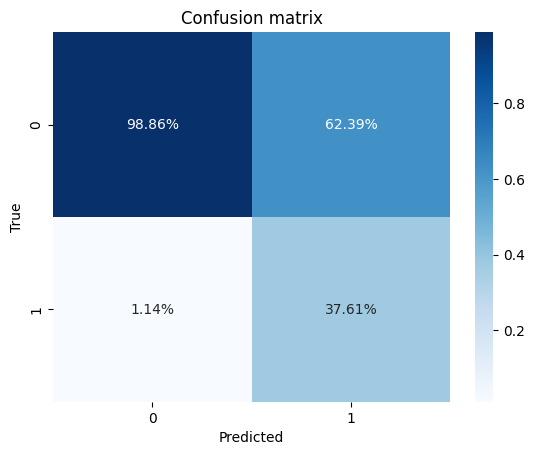

In [81]:
y_pred_best = (probs >= best_t).astype(int)
cm = confusion_matrix(y_test, y_pred_best, normalize='pred')

sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')

plt.title('Confusion matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()